# Badanie wpływu hiperparametrów na proces uczenia

## Funkcje pomocnicze

In [95]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from training import experiments_config, base_params
from dqnagent import EPSILON_MIN
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="darkgrid")

def load_metrics(experiment_name):
    """Safely retrieves metrics stored in JSON format."""
    path = f"metrics/{experiment_name}.json"
    if not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)

baseline_metrics = load_metrics("baseline")
if not baseline_metrics:
    print("Error: Baseline metrics not found! Please check 'metrics/baseline.json'.")
else:
    print("Baseline metrics successfully initialized.")

time_data = {"baseline": (baseline_metrics.get("training_time", 0),np.average(baseline_metrics.get("length_history", 0)))} if baseline_metrics else {}

Baseline metrics successfully initialized.


In [96]:
def plot_learning_curves(param_name, param_values, baseline_metrics, base_params, time_dict):
    """
    Renders moving average reward trajectories for a specific hyperparameter configuration.
    """
    if not baseline_metrics:
        print("Baseline data unavailable.")
        return
        
    plt.figure(figsize=(10, 6))
    
    # Reference plot for the baseline execution
    plt.plot(
        baseline_metrics["moving_avg_history"],
        label=f"baseline = {base_params.get(param_name, 'N/A')}",
        linewidth=1.5,
        color="black",
        linestyle="--",
    )
    
    # Iterative tracking of parameter mutations
    for val in param_values:
        val_str = "_".join(map(str, val)) if isinstance(val, tuple) else str(val)
        exp_name = f"{param_name}_{val_str}"
        metrics = load_metrics(exp_name)
        
        if metrics:
            plt.plot(
                metrics["moving_avg_history"],
                label=f"{param_name} = {val_str}",
                linewidth=2,
            )
            time_dict[exp_name] = (metrics.get("training_time", 0),np.average(metrics.get("length_history", 0)))
        else:
            print(f"Skipped {exp_name} - metrics missing.")
            
    plt.title(f"Porównanie hiperparametru: {param_name}", fontsize=14, pad=15)
    plt.xlabel("Epizod", fontsize=12)
    plt.ylabel("Średnia krocząca z nagrody (okno=50)", fontsize=12)
    plt.axhline(y=200, color="r", linestyle=":", alpha=0.5, label="Rozwiązano środowisko (200)")
    plt.legend(fontsize=11, loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_epsilon_decay_curves(param_values, baseline_metrics, base_params):
    """
    Renders exploration rate decay schedules against the baseline threshold.
    """
    if not baseline_metrics:
        return
        
    plt.figure(figsize=(10, 6))
    plt.plot(
        baseline_metrics["epsilon_history"],
        label=f"baseline = {base_params.get('epsilon_decay', 'N/A')}",
        linewidth=1.5,
        color="black",
        linestyle="--",
    )
    
    for val in param_values:
        val_str = "_".join(map(str, val)) if isinstance(val, tuple) else str(val)
        exp_name = f"epsilon_decay_{val_str}"
        metrics = load_metrics(exp_name)
        if metrics:
            plt.plot(
                metrics["epsilon_history"],
                label=f"epsilon_decay = {val_str}",
                linewidth=2,
            )
            
    plt.axhline(y=EPSILON_MIN, color="r", linestyle=":", alpha=0.5, label="Dolna granica epsilon")
    plt.title("Porównanie historii epsilon dla różnych wartości epsilon_decay", fontsize=14, pad=15)
    plt.xlabel("Epizod", fontsize=12)
    plt.ylabel("Wartość Epsilon", fontsize=12)
    plt.legend(fontsize=11, loc="upper right")
    plt.tight_layout()
    plt.show()

In [97]:
def get_moving_average(data, window):
    if len(data) < window:
        return data  # Zwróć oryginalne dane, jeżeli jest ich mniej niż okno
    sma = np.convolve(data, np.ones(window) / window, mode='valid')
    return np.concatenate((np.full(window - 1, np.nan), sma))

def plot_loss_curves( param_name, param_values, baseline_metrics, base_params,window_size=50):
    sns.set_theme(style="darkgrid")
    
    baseline_metrics = load_metrics("baseline")
    if not baseline_metrics:
        print("Nie znaleziono pliku z metrykami baseline'u!")
        return


    plt.figure(figsize=(10, 6))

    if "loss_history" in baseline_metrics:
        baseline_loss_ma = get_moving_average(baseline_metrics["loss_history"], window_size)
        plt.plot(
            baseline_loss_ma,
            label=f"baseline = {base_params.get(param_name, 'N/A')}",
            linewidth=1.5,
            color="black",
            linestyle="--",
        )

    for val in param_values:
        val_str = "_".join(map(str, val)) if isinstance(val, tuple) else str(val)
        exp_name = f"{param_name}_{val_str}"
        metrics = load_metrics(exp_name)

        if metrics and "loss_history" in metrics:
            loss_ma = get_moving_average(metrics["loss_history"], window_size)
            plt.plot(
                loss_ma,
                label=f"{param_name} = {val_str}",
                linewidth=2,
            )
        else:
            print(f"Pominięto {exp_name} - brak danych o stracie.")

    plt.title(f"Porównanie hiperparametru na podstawie straty (Loss): {param_name}", fontsize=14, pad=15)
    plt.xlabel("Epizod", fontsize=12)
    plt.ylabel(f"Średnia krocząca straty (okno={window_size})", fontsize=12)
    
    plt.legend(fontsize=11, loc="upper right")
    plt.tight_layout()
    plt.show()


## Współczynnik uczenia

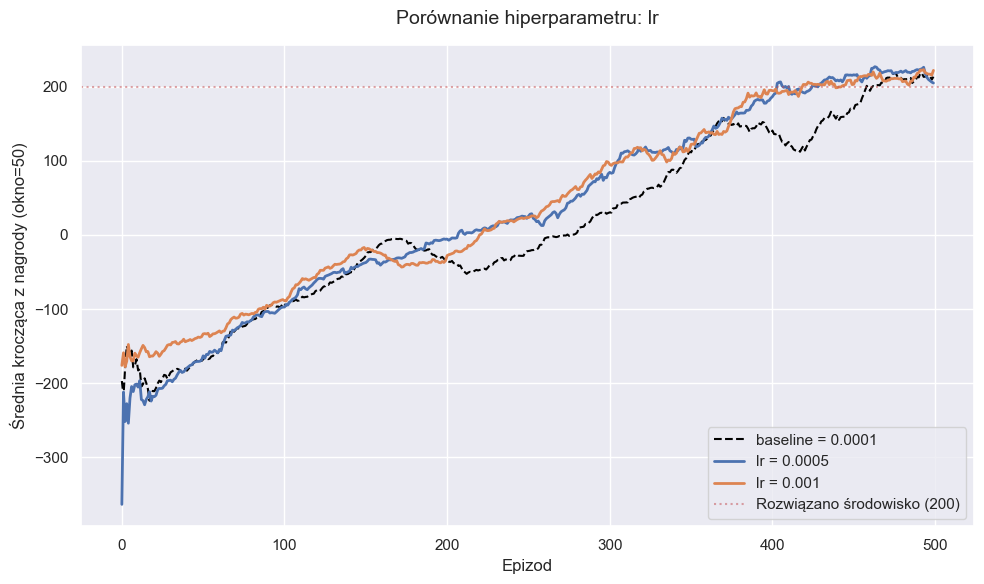

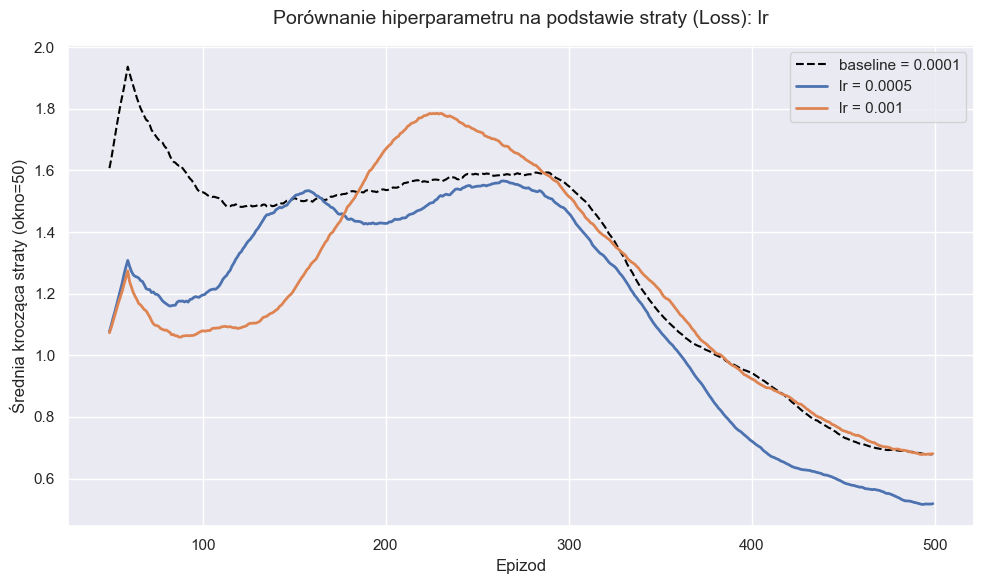

In [98]:
param = "lr"
if param in experiments_config:
    plot_learning_curves(param, experiments_config[param], baseline_metrics, base_params, time_data)
    plot_loss_curves(param, experiments_config[param], baseline_metrics, base_params)

Wyższe wartości lr (0.001 i 0.0005) osiągają próg rozwiązania środowiska szybciej i unikają plateau widocznego dla baseline'u (lr=0.0001) w okolicach epizodów 150–250. Wczesny spike lr=0.0005 jest artefaktem agresywniejszych aktualizacji wag, który szybko zanika. Wszystkie trzy konfiguracje osiągają zbliżony wynik końcowy (~210–215), więc różnice dotyczą tempa, nie jakości finalnej polityki.\
lr=0.001 oferuje najlepszy kompromis między szybkością konwergencji a stabilnością treningu.\

Szczyt straty lr=0.001 (~1.78) w okolicach epizodu 230 - dokładnie w tym miejscu krzywa nagrody dla tej konfiguracji przechodzi przez chwilowe spowolnienie. To potwierdza, że nie jest to artefakt losowy, lecz rzeczywista faza reorganizacji polityki. Po epizodzie 300 wszystkie trzy konfiguracje zbiegają do podobnego poziomu straty (~0.6–0.7), co jest spójne z wyrównaniem krzywych nagrody w końcowej fazie.

## Gamma (discount rate)

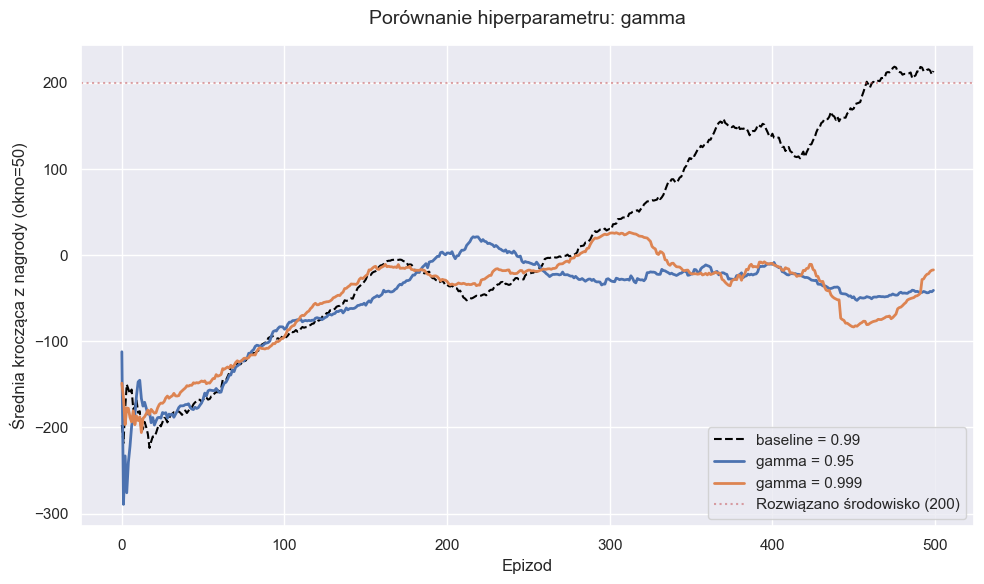

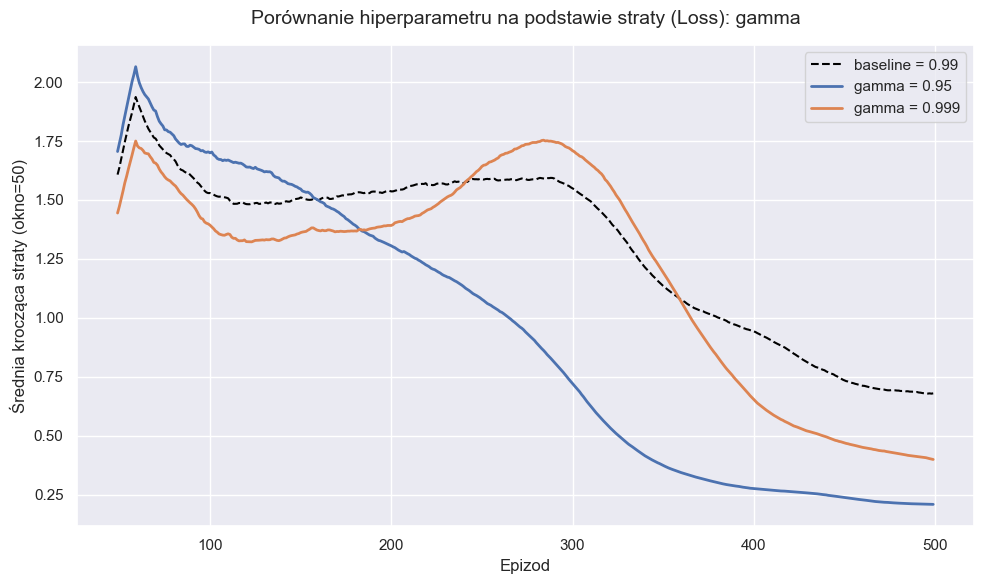

In [99]:
param = "gamma"
if param in experiments_config:
    plot_learning_curves(param, experiments_config[param], baseline_metrics, base_params, time_data)
    plot_loss_curves(param, experiments_config[param], baseline_metrics, base_params)

Baseline (gamma=0.99) jako jedyny przekracza próg 200 punktów, osiągając go około epizodu 420 i kontynuując wzrost. Gamma=0.95 i gamma=0.999 utknęły w okolicach zera po epizodzie 200 i nie wykazują dalszej poprawy — w przypadku gamma=0.999 widoczna jest nawet wyraźna degradacja po epizodzie 350.\
Zbyt niska gamma (0.95) powoduje zbyt krótkowzroczną politykę — agent nie docenia odległych nagród kluczowych przy lądowaniu. Zbyt wysoka (0.999) wprowadza niestabilność, bo agent nadmiernie propaguje odległe, niepewne nagrody, co destabilizuje uczenie. Agent przypisuje niemal równą wagę nagrodzie za 1 krok i za 500 kroków, co fundamentalnie zaburza hierarchię celów (miękkie lądowanie vs. utrzymanie się w powietrzu)

Niska strata przy gamma=0.95 oznacza, że sieć bardzo dobrze aproksymuje Q-wartości krótkoterminowego horyzontu - ale te wartości są fundamentalnie złe z perspektywy zadania. Agent "nauczył się" precyzyjnie wyceniać błędną politykę. Podobnie gamma=0.999 redukuje stratę do ~0.4 po epizodzie 300, ale jednocześnie krzywa nagrody degraduje - sieć stabilizuje się wokół nieprawidłowych wartości Q propagowanych przez zbyt długi horyzont.

## Epsilon

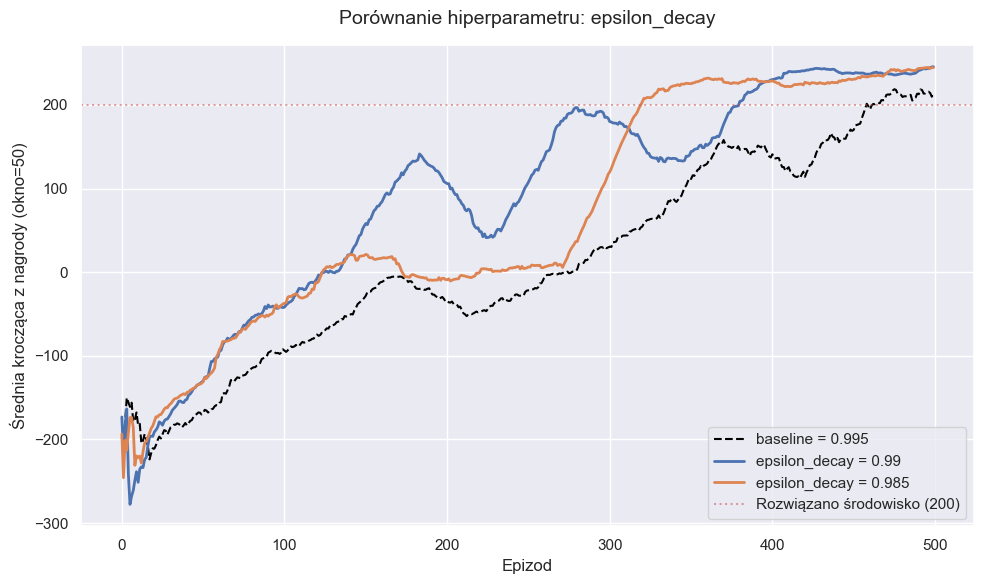

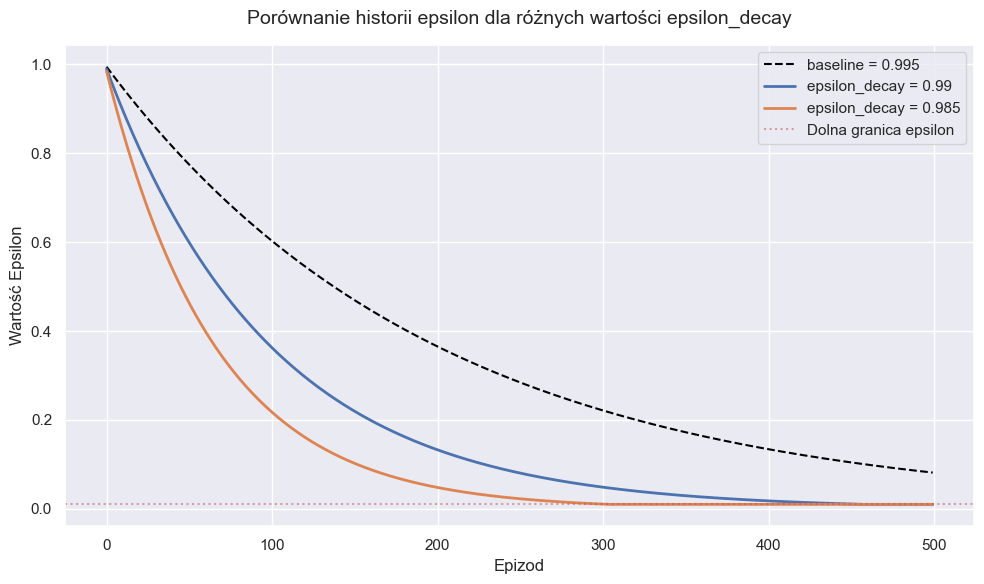

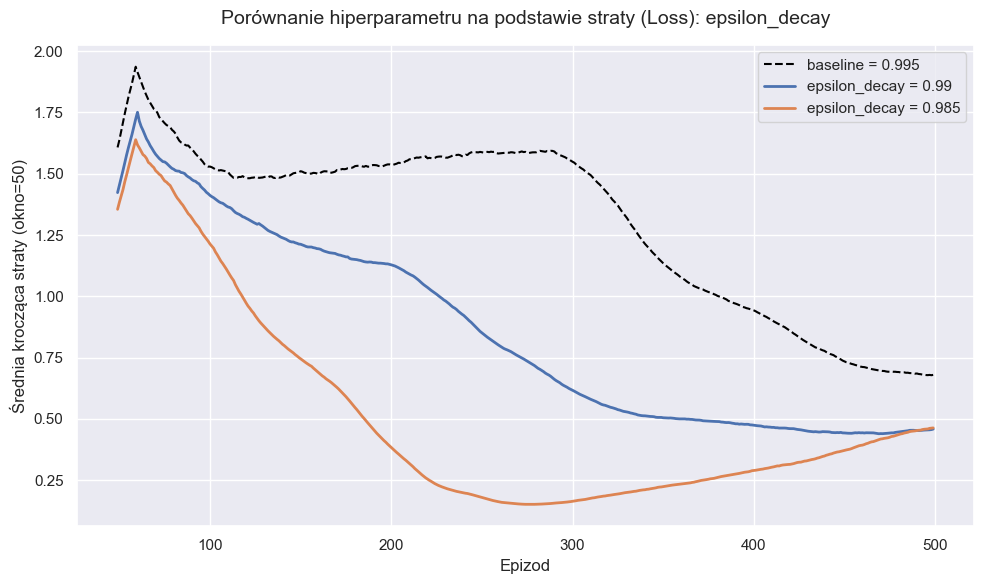

In [100]:
param = "epsilon_decay"
if param in experiments_config:
    plot_learning_curves(param, experiments_config[param], baseline_metrics, base_params, time_data)
    plot_epsilon_decay_curves(experiments_config[param], baseline_metrics, base_params)
    plot_loss_curves(param, experiments_config[param], baseline_metrics, base_params)

Szybszy zanik wartości epsilon_decay (0.985 i 0.99) powoduje, że agent przechodzi do fazy eksploatacji szybciej, co przyspiesza uczenie się skutecznej strategii. Widoczne lokalne minimum niebieskiej krzywej (~epizod 220) to klasyczny efekt zbyt wczesnego "zamrożenia" eksploracji przy decay=0.99 — epsilon osiąga minimum już ok. epizodu 250, przez co agent traci zdolność wychodzenia z lokalnych minimów. Decay=0.985 unika tego problemu, bo epsilon spada jeszcze szybciej do dolnej granicy i agent wcześniej w pełni przechodzi w tryb eksploatacji stabilnej polityki.\
Baseline (0.995) utrzymuje wysoką eksplorację przez niemal cały trening — epsilon nadal wynosi ~0.4 w epizodzie 200 — co tłumaczy wolniejszy, ale bardziej monotoniczny wzrost bez głębokich spadków średniej wartości nagrody.\
Zbyt wolny decay (baseline) hamuje konwergencję przez nadmierną eksplorację, natomiast decay=0.99 generuje niestabilność w środkowej fazie przez nieoptymalne tempo przejścia exploration-exploitation. Istnieje wyraźne "okno" optymalnego decay, gdzie agent zdąży zebrać wystarczającą wiedzę przed zakończeniem eksploracji.

## Wielkość warstw ukrytych

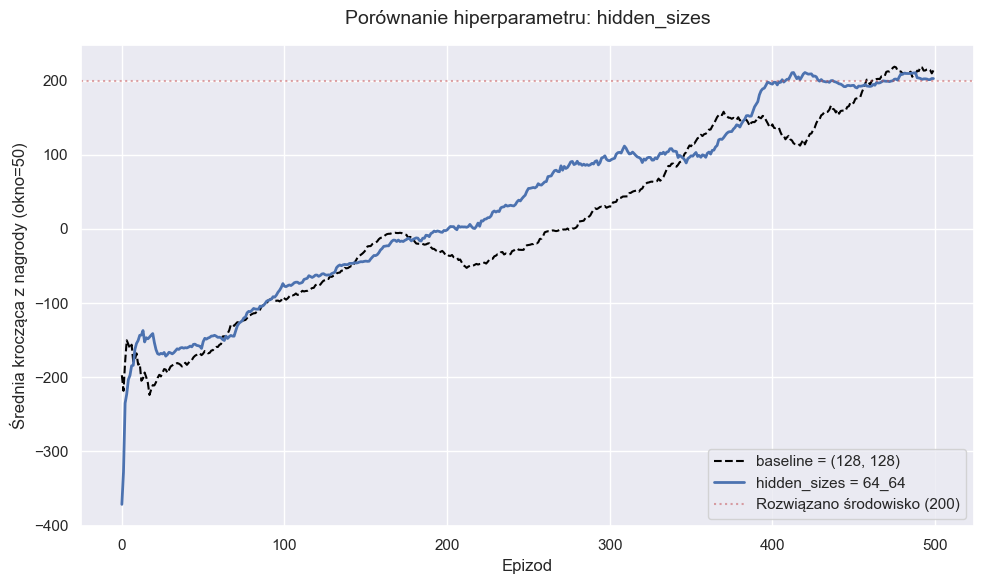

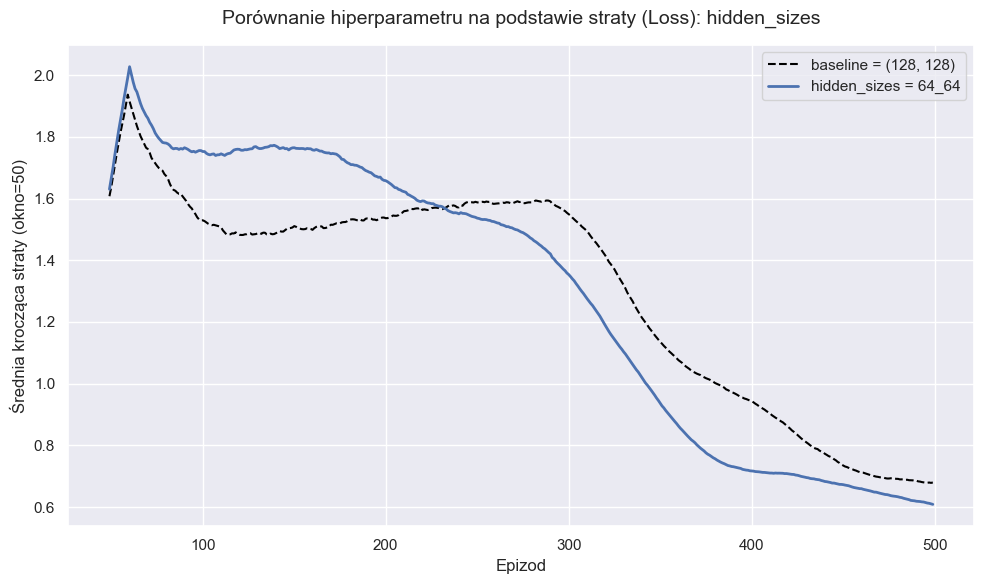

In [101]:
param = "hidden_sizes"
if param in experiments_config:
    plot_learning_curves(param, experiments_config[param], baseline_metrics, base_params, time_data)
    plot_loss_curves(param, experiments_config[param], baseline_metrics, base_params)

Z wykresu wynika, że mniej skomplikowana sieć radzi sobie porównywalnie dobrze co baseline. LunarLander jest zadaniem o stosunkowo niskiej złożoności (przestrzeń stanów 8D, 4 akcje), więc mniejsza sieć 64x64 jest wystarczająca.

## Wielkość paczki

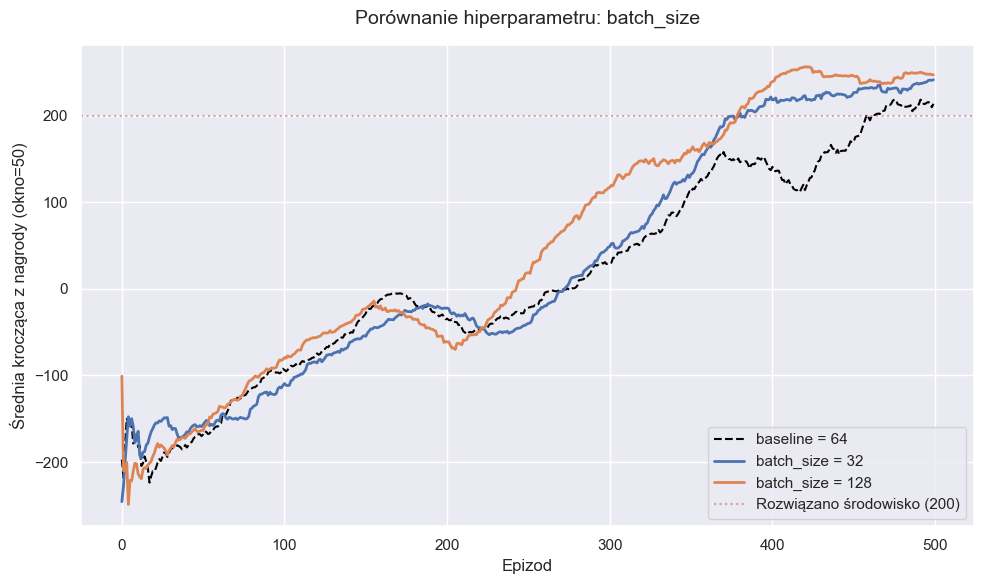

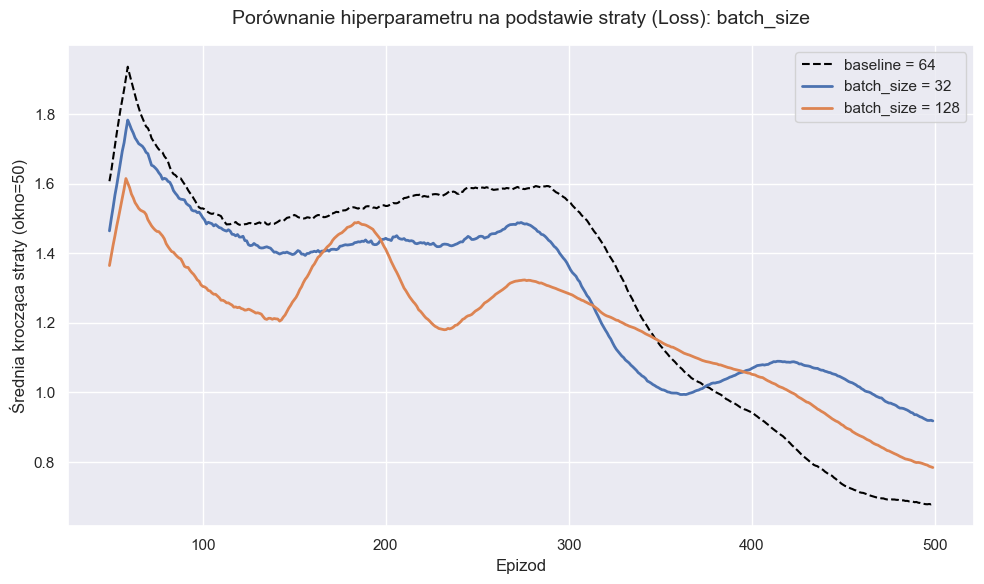

In [102]:
param = "batch_size"
if param in experiments_config:
    plot_learning_curves(param, experiments_config[param], baseline_metrics, base_params, time_data)
    plot_loss_curves(param, experiments_config[param], baseline_metrics, base_params)

Większy batch (128) stabilizuje gradienty poprzez uśrednianie po większej liczbie przejść z replay buffer, co przekłada się na bardziej konsekwentne aktualizacje sieci Q w późnej fazie treningu. Mniejszy batch (32) wprowadza zbyt dużą wariancję gradientów, co nie daje istotnej przewagi nad baseline.

## Częstotliwość aktualizacji sieci target

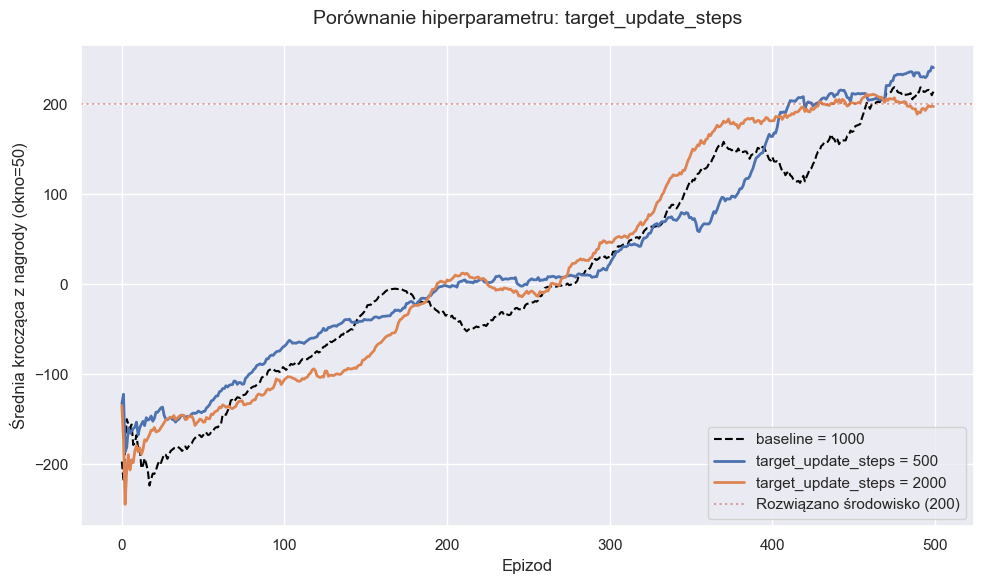

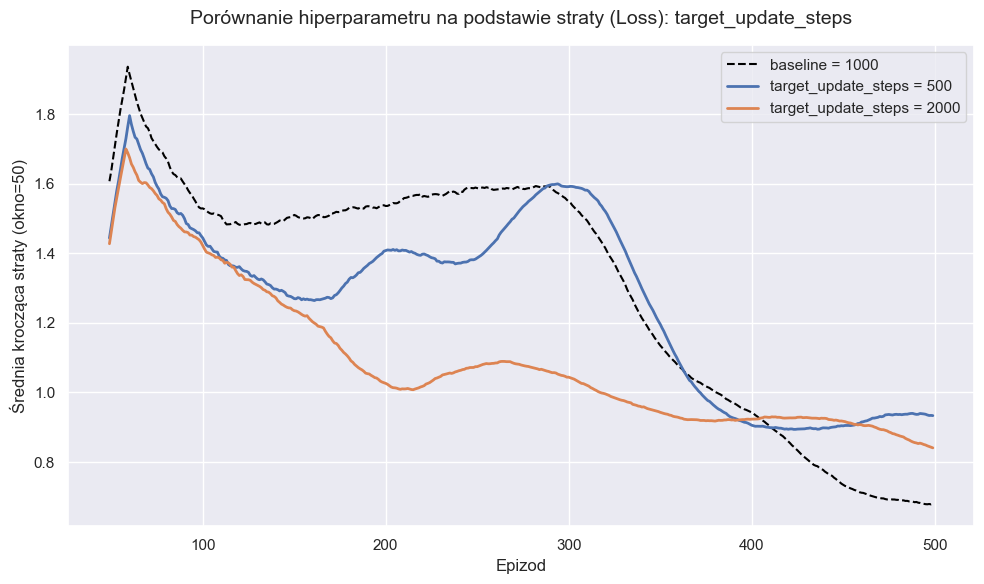

In [103]:
param = "target_update_steps"
if param in experiments_config:
    plot_learning_curves(param, experiments_config[param], baseline_metrics, base_params, time_data)
    plot_loss_curves(param, experiments_config[param], baseline_metrics, base_params)

Częstotliwość aktualizacji target network ma marginalny wpływ na wynik końcowy w tym zadaniu

## Czas wykonania i średnia liczba kroków w epizodzie

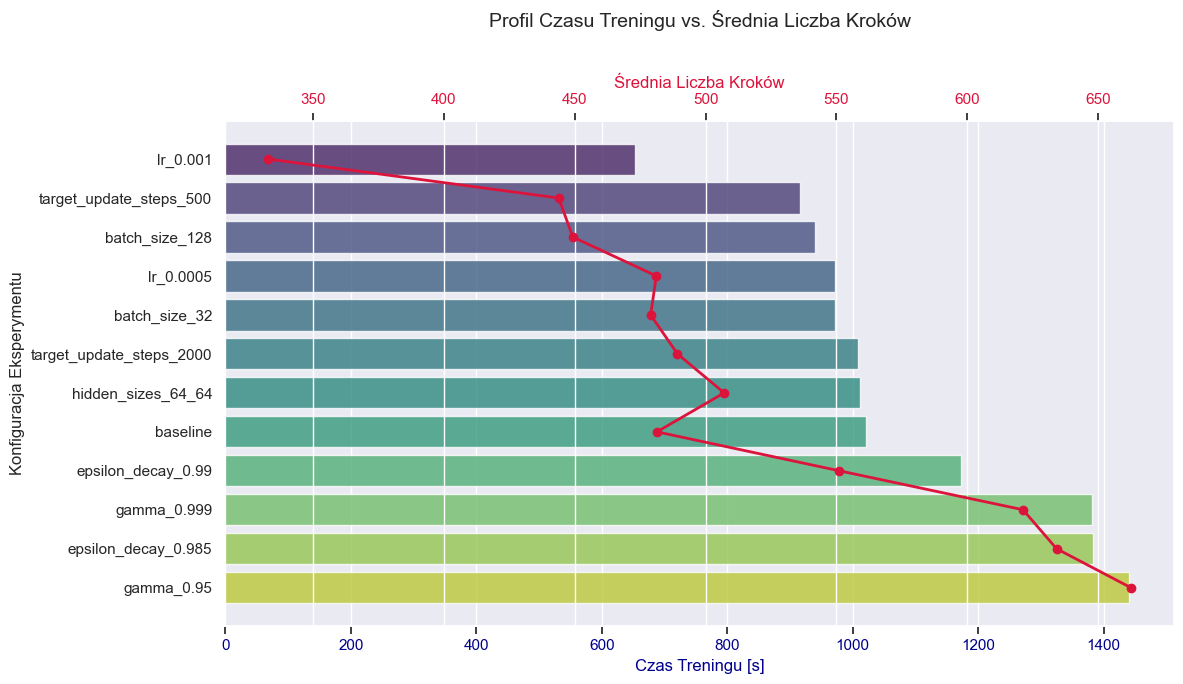

In [104]:
if time_data:
    # Sort configurations sequentially by training time duration
    sorted_metrics = sorted(time_data.items(), key=lambda x: x[1][0])
    names = [item[0] for item in sorted_metrics]
    times = [item[1][0] for item in sorted_metrics]
    avg_steps = [item[1][1] for item in sorted_metrics]
    
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # Primary Axis: Horizontal Bar Chart for Execution Time
    sns.barplot(x=times, y=names, palette="viridis", alpha=0.8, ax=ax1)
    ax1.set_title("Profil Czasu Treningu vs. Średnia Liczba Kroków", fontsize=14, pad=35)
    ax1.set_xlabel("Czas Treningu [s]", color="darkblue", fontsize=12)
    ax1.set_ylabel("Konfiguracja Eksperymentu", fontsize=12)
    ax1.tick_params(axis='x', labelcolor="darkblue")
    
    # Secondary Axis: Overlaid Line/Marker Chart for Step Densities
    ax2 = ax1.twiny()
    ax2.plot(avg_steps, names, color="crimson", marker="o", linewidth=2, label="Śr. kroki")
    ax2.set_xlabel("Średnia Liczba Kroków", color="crimson", fontsize=12)
    ax2.tick_params(axis='x', labelcolor="crimson")
    
    plt.tight_layout()
    plt.show()
else:
    print("No benchmark execution run times have been captured yet.")

Istnieje wyraźna odwrotna zależność między czasem treningu a średnią liczbą kroków. Agent który szybko uczy się skutecznej polityki, kończy epizody sprawniej (ląduje lub rozbija się szybciej), zamiast "krążyć" przez setki kroków.\
Gamma=0.95, który mimo słabych wyników nagród generuje najdłuższe epizody - przez krótkowzroczną politykę, agent unika rozbicia się, ale nie potrafi wylądować. (patrz: `records/gamma_0.95/rl-video-episode-200/300/400`)

# Wnioski

Kluczowe hiperparametry do optymalizacji dla DDQN w LunarLander to przede wszystkim lr, epsilon_decay i batch_size.\
lr, epsilon_decay i batch_size to jedyne trzy hiperparametry, gdzie niska strata i wysoka nagroda są ze sobą spójne, co świadczy o rzeczywistej poprawie jakości uczenia, a nie jedynie o artefaktach skali Q-wartości. Jednocześnie strata ujawnia, że dla gamma i batch_size nie należy interpretować jej wartości bezwzględnej w oderwaniu od nagrody, gdyż może prowadzić do błędnych wniosków o jakości polityki.

*Należy zaznaczyć, że wszystkie przedstawione wyniki zostały zebrane na pojedynczej wartości ziarna dla generatorów liczb pseudolosowych, co oznacza, że obserwowane różnice między konfiguracjami mogą częściowo wynikać z wariancji losowej, a nie rzeczywistego wpływu hiperparametrów — wiarygodne wnioski wymagałyby uśrednienia wyników z co najmniej 3–5 niezależnych przebiegów.*